# Fase 2: Modelado Predictivo

Tras completar el Análisis Exploratorio de Datos (EDA), entramos en la fase de construcción del activo tecnológico. Nuestro objetivo es desarrollar un sistema de Machine Learning capaz de clasificar con alta precisión la etapa cronológica del cultivo basándose en su respuesta biofísica y estructural.

Para garantizar que el modelo sea robusto ante escenarios reales de negocio, implementare la siguiente estrategia:
1. **Ingeniería de Características (Feature Engineering):** Creación de variables matemáticas no lineales y sinergias multiespectrales para extraer el máximo valor de los datos.
2. **Validación Cruzada por Grupos (GroupKFold):** Evaluaremos los modelos asegurando que se prueben con predios geográficos completamente nuevos que el sistema nunca vio en el entrenamiento. Esto evita el sobreajuste y garantiza el éxito de un despliegue en producción.

In [49]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, GridSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

RANDOM_STATE = 42
FILE_PATH = "DATA SET CSV.csv"

df = pd.read_csv(FILE_PATH)

print("Dimensiones:", df.shape)
display(df.head())

print("\nTipos de datos:")
display(df.dtypes.to_frame("dtype"))

print("\nValores nulos:")
display(df.isnull().sum().to_frame("nulos"))

Dimensiones: (139, 20)


,ID,x,y,edad_aprox,ndvi_media,ndvi_max,ndvi_std,gndvi_media,ndre_media,ndre_std,savi_media,savi_std,area_m2,perimetro_m,altura_m,diam_min,diam_max,relac_form,diam_circu,predio
0,AGROSILV_001,569648.9219,2206002.619,10,0.681852,0.881289,0.136940,0.393516,0.084521,0.078242,1.022775,0.205367,2.059,13.222,0.986084,2.103164,2.152211,0.977211,2.356944,silvicultores
1,AGROSILV_002,569648.5976,2206000.348,10,0.682127,0.922071,0.113145,0.368540,0.065847,0.091895,1.023393,0.169441,3.626,25.171,1.392578,2.747473,3.615655,0.759883,3.627464,silvicultores
2,AGROSILV_003,569648.0896,2205997.971,10,0.666949,0.872402,0.114971,0.348688,0.055619,0.084720,1.000318,0.172235,3.450,27.269,1.193359,3.091506,3.378309,0.915105,3.629513,silvicultores
3,AGROSILV_004,569647.5716,2205995.588,10,0.631413,0.842249,0.157529,0.317238,0.045486,0.076575,0.946976,0.237027,1.259,10.810,0.780762,1.588586,1.876803,0.846432,2.062912,silvicultores
4,AGROSILV_005,569647.1305,2205993.296,10,0.678549,0.953309,0.130447,0.345647,0.048250,0.093811,1.017619,0.196019,3.496,23.056,1.595947,3.012396,3.116213,0.966685,3.406569,silvicultores



Tipos de datos:


,dtype
ID,object
x,float64
y,float64
edad_aprox,int64
ndvi_media,float64
ndvi_max,float64
ndvi_std,float64
gndvi_media,float64
ndre_media,float64
ndre_std,float64



Valores nulos:


,nulos
ID,0
x,0
y,0
edad_aprox,0
ndvi_media,0
ndvi_max,0
ndvi_std,0
gndvi_media,0
ndre_media,0
ndre_std,0


## Segmentación del Target y Definición de Límites Cronológicos

Para optimizar la precisión del negocio, acotamos nuestro universo de estudio a las etapas de desarrollo críticas (entre 0 y 15 años). A partir de esto, transformamos la edad continua en etiquetas de clase bien definidas que representen ciclos operativos reales en el campo. 

También evaluamos la distribución cruzada por predio para entender el nivel de desbalance de clases al que se enfrentarán nuestros clasificadores.

In [52]:
# Filtrado de rango de edad objetivo
df = df[df["edad_aprox"].between(0, 15)].copy()

# Definición de la función de segmentación cronológica
def asignar_rango_edad(x):
    if 0 <= x <= 5:
        return "0-5"
    elif 6 <= x <= 9:
        return "6-9"
    elif 10 <= x <= 15:
        return "10-15"
    else:
        return np.nan

df["edad_clase"] = df["edad_aprox"].apply(asignar_rango_edad)

print("Distribución de clases:")
display(df["edad_clase"].value_counts().sort_index())

print("\nDistribución por predio y clase:")
display(pd.crosstab(df["predio"], df["edad_clase"]))

Distribución de clases:


edad_clase
0-5      63
10-15    43
6-9      33
Name: count, dtype: int64


Distribución por predio y clase:


edad_clase,0-5,10-15,6-9
predio,,,
albinos,40,24,15
silvicultores,23,19,18


## Ingeniería de Características (Feature Engineering)

Los algoritmos de Machine Learning expanden su capacidad predictiva cuando les proporcionamos combinaciones de variables que capturan la geometría del cultivo y su firma espectral de forma conjunta.

En esta sección, generamos variables derivadas utilizando:
- **Transformaciones logarítmicas y cuadráticas:** Para estabilizar varianzas y capturar dinámicas no lineales (`log_area`, `diam_max_sq`, `altura_log`).
- **Relaciones geométricas y de densidad:** Índices que vinculan la altura y el diámetro de la copa (`rel_altura_diam`, `densidad_geom`).
- **Interacciones Multiespectrales y Estructurales:** Cruces entre el área física detectada y el vigor fotosintético medido por los sensores (`interaccion_area_ndre`, `interaccion_ndre_gndvi`).

In [55]:
df_model = df.copy()

# Transformaciones matemáticas individuales
df_model["log_area"] = np.log1p(df_model["area_m2"])
df_model["diam_max_sq"] = df_model["diam_max"] ** 2
df_model["altura_log"] = np.log1p(df_model["altura_m"])

# Proporciones estructurales
df_model["rel_altura_diam"] = df_model["altura_m"] / (df_model["diam_max"] + 1e-6)
df_model["densidad_geom"] = df_model["area_m2"] / (df_max:=df_model["diam_max"] + 1e-6)

# Variables de interacción biofísica
df_model["interaccion_diam_altura"] = df_model["diam_max"] * df_model["altura_m"]
df_model["interaccion_area_ndre"] = df_model["area_m2"] * df_model["ndre_media"]
df_model["interaccion_ndre_gndvi"] = df_model["ndre_media"] * df_model["gndvi_media"]

print("\nVista rápida de variables derivadas:")
display(df_model.head())


Vista rápida de variables derivadas:


,ID,x,y,edad_aprox,ndvi_media,ndvi_max,ndvi_std,gndvi_media,ndre_media,ndre_std,...,predio,edad_clase,log_area,diam_max_sq,altura_log,rel_altura_diam,densidad_geom,interaccion_diam_altura,interaccion_area_ndre,interaccion_ndre_gndvi
0,AGROSILV_001,569648.9219,2206002.619,10,0.681852,0.881289,0.136940,0.393516,0.084521,0.078242,...,silvicultores,10-15,1.118088,4.632012,0.686165,0.458172,0.956690,2.122261,0.174029,0.033260
1,AGROSILV_002,569648.5976,2206000.348,10,0.682127,0.922071,0.113145,0.368540,0.065847,0.091895,...,silvicultores,10-15,1.531693,13.072961,0.872371,0.385152,1.002861,5.035082,0.238761,0.024267
2,AGROSILV_003,569648.0896,2205997.971,10,0.666949,0.872402,0.114971,0.348688,0.055619,0.084720,...,silvicultores,10-15,1.492904,11.412972,0.785434,0.353241,1.021221,4.031535,0.191886,0.019394
3,AGROSILV_004,569647.5716,2205995.588,10,0.631413,0.842249,0.157529,0.317238,0.045486,0.076575,...,silvicultores,10-15,0.814922,3.522390,0.577041,0.416006,0.670821,1.465336,0.057267,0.014430
4,AGROSILV_005,569647.1305,2205993.296,10,0.678549,0.953309,0.130447,0.345647,0.048250,0.093811,...,silvicultores,10-15,1.503188,9.710783,0.953951,0.512143,1.121874,4.973311,0.168682,0.016677


## Aislamiento de Predictores, Codificación y Arquitectura del Pipeline

Para asegurar un desarrollo ético y agnóstico del modelo, **excluimos la variable 'predio' de los predictores**. Queremos que el algoritmo aprenda patrones físicos y biológicos transferibles, no que memorice nombres de terrenos.

Establecemos un pipeline automatizado que resuelve de forma secuencial:
1. **Imputación:** Reemplazo de valores nulos o infinitos mediante la mediana.
2. **Escalamiento:** Estandarización de características (`StandardScaler`) para garantizar la convergencia de modelos lineales.
3. **Manejo de Desbalance:** Incorporación de sobremuestreo estadístico (`RandomOverSampler`) para que las clases minoritarias tengan el mismo peso durante el ajuste.

In [58]:
target = "edad_clase"
group_col = "predio"

# Lista definitiva de variables predictoras seleccionadas
feature_cols = [
    "altura_m",
    "altura_log",
    "area_m2",
    "log_area",
    "diam_max",
    "diam_max_sq",
    "rel_altura_diam",
    "densidad_geom",
    "interaccion_diam_altura",
    "ndre_media",
    "interaccion_area_ndre",
    "interaccion_ndre_gndvi"
]

X = df_model[feature_cols].copy()
y = df_model[target].copy()
groups = df_model[group_col].copy()

# Tratamiento de inconsistencias numéricas
X = X.replace([np.inf, -np.inf], np.nan).reset_index(drop=True)
y = y.reset_index(drop=True)
groups = groups.reset_index(drop=True)

# Codificación de etiquetas del target
label_encoder = LabelEncoder()
y_encoded = pd.Series(label_encoder.fit_transform(y)).reset_index(drop=True)

print("Clases codificadas:")
for clase, codigo in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{clase} -> {codigo}")

# Configuración del transformador numérico y preprocesador global
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, feature_cols)
    ]
)

# Definición del esquema GroupKFold para validación espacial robusta
n_groups = groups.nunique()
n_splits = min(2, n_groups)
gkf = GroupKFold(n_splits=n_splits)

print("\nNúmero de grupos geográficos independientes:", n_groups)
print("n_splits usados en GroupKFold:", n_splits)

Clases codificadas:
0-5 -> 0
10-15 -> 1
6-9 -> 2

Número de grupos geográficos independientes: 2
n_splits usados en GroupKFold: 2


## Entrenamiento Competitivo y Optimización de Hiperparámetros (GridSearchCV)

Lanzamos un entrenamiento competitivo bajo el esquema de validación cruzada espacial (`GroupKFold`). Evaluaremos dos arquitecturas con filosofías matemáticas distintas utilizando como métrica principal el `balanced_accuracy` para mitigar los efectos del desbalance de clases:
1. **Regresión Logística:** Un modelo lineal de alta interpretabilidad, optimizando el parámetro de regularización $C$.
2. **Random Forest Classifier:** Un modelo ensamblado basado en árboles de decisión no lineales, buscando la combinación ideal de profundidad, número de estimadores y criterios de división.

In [61]:
# --- MODELO A: REGRESIÓN LOGÍSTICA ---
logit_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("oversample", RandomOverSampler(random_state=RANDOM_STATE)),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE, solver="lbfgs"))
])

logit_param_grid = {"model__C": [0.01, 0.1, 1, 10, 50]}

logit_grid = GridSearchCV(estimator=logit_pipe, param_grid=logit_param_grid, cv=gkf, scoring="balanced_accuracy", n_jobs=1, error_score="raise")
logit_grid.fit(X, y_encoded, groups=groups)

print("Mejor Regresión Logística Params:", logit_grid.best_params_)
print("Mejor score CV (Balanced Accuracy):", logit_grid.best_score_)


# --- MODELO B: RANDOM FOREST ---
rf_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("oversample", RandomOverSampler(random_state=RANDOM_STATE)),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
])

rf_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [4, 6, 8, None],
    "model__min_samples_leaf": [1, 2, 3],
    "model__min_samples_split": [2, 4, 6]
}

rf_grid = GridSearchCV(estimator=rf_pipe, param_grid=rf_param_grid, cv=gkf, scoring="balanced_accuracy", n_jobs=1, error_score="raise")
rf_grid.fit(X, y_encoded, groups=groups)

print("\nMejor Random Forest Params:", rf_grid.best_params_)
print("Mejor score CV (Balanced Accuracy):", rf_grid.best_score_)

Mejor Regresión Logística Params: {'model__C': 10}
Mejor score CV (Balanced Accuracy): 0.8182261208576999

Mejor Random Forest Params: {'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Mejor score CV (Balanced Accuracy): 0.7493177387914229


## Evaluación Comparativa y Selección de la Arquitectura Ganadora

Comparamos el rendimiento de ambos candidatos bajo las predicciones de validación cruzada fuera de la muestra (*out-of-sample*). Analizaremos métricas globales (`Accuracy`, `Balanced Accuracy` y `F1-Macro`) para seleccionar el modelo que demuestre la mejor capacidad de generalización sobre terrenos agrícolas desconocidos.

In [63]:
best_models = {
    "LogisticRegression": logit_grid.best_estimator_,
    "RandomForest": rf_grid.best_estimator_
}

results = []
cv_predictions = {}

for name, model in best_models.items():
    y_pred_cv = cross_val_predict(model, X, y_encoded, cv=gkf, groups=groups, method="predict", n_jobs=1)
    
    acc = accuracy_score(y_encoded, y_pred_cv)
    bal_acc = balanced_accuracy_score(y_encoded, y_pred_cv)
    f1_macro = f1_score(y_encoded, y_pred_cv, average="macro")

    results.append({
        "modelo": name,
        "accuracy_cv": acc,
        "balanced_accuracy_cv": bal_acc,
        "f1_macro_cv": f1_macro
    })
    cv_predictions[name] = y_pred_cv

results_df = pd.DataFrame(results).sort_values(["balanced_accuracy_cv", "f1_macro_cv"], ascending=False).reset_index(drop=True)

print("Comparación de modelos candidatos:")
display(results_df)

best_model_name = results_df.loc[0, "modelo"]
best_model = best_models[best_model_name]
y_pred_best = cv_predictions[best_model_name]

print(f"\n>>>> Arquitectura seleccionada para producción: {best_model_name} <<<<")

Comparación de modelos candidatos:


,modelo,accuracy_cv,balanced_accuracy_cv,f1_macro_cv
0,LogisticRegression,0.812950,0.808853,0.797141
1,RandomForest,0.784173,0.756256,0.753402



>>>> Arquitectura seleccionada para producción: LogisticRegression <<<<


## Diagnóstico Detallado del Modelo Seleccionado

Analizamos a fondo el comportamiento del modelo ganador. Desglosamos el reporte de clasificación para observar la *Precisión* y *Recall* por cada categoría cronológica, y renderizamos tanto la **Matriz de Confusión Absoluta** como la **Normalizada**. 

Esto nos permite identificar si el algoritmo presenta alguna confusión sistemática en las fronteras de edad de los cultivos (p. ej., confundir plantas maduras con jóvenes).

Reporte de clasificación detallado:

              precision    recall  f1-score   support

         0-5     0.9818    0.8571    0.9153        63
       10-15     0.8611    0.7209    0.7848        43
         6-9     0.5833    0.8485    0.6914        33

    accuracy                         0.8129       139
   macro avg     0.8088    0.8089    0.7971       139
weighted avg     0.8499    0.8129    0.8217       139



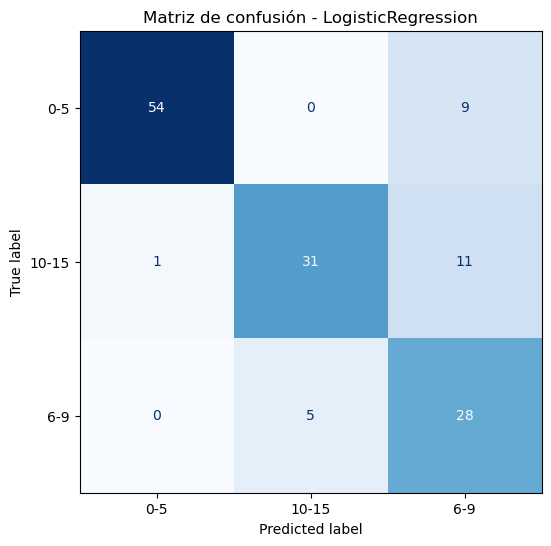

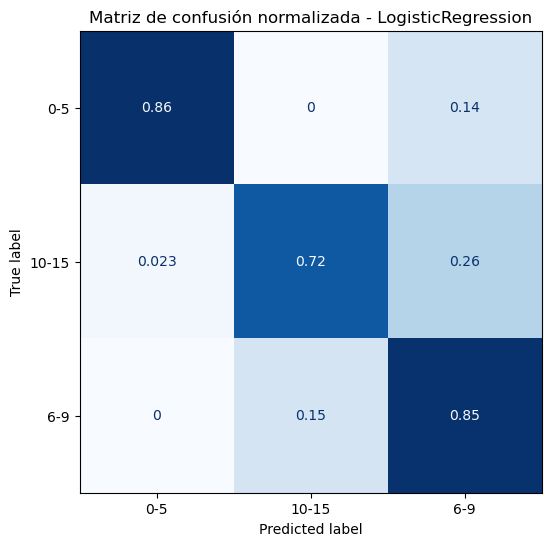

In [65]:
print("Reporte de clasificación detallado:\n")
print(classification_report(y_encoded, y_pred_best, target_names=label_encoder.classes_, digits=4))

# Matriz de Confusión Absoluta
cm = confusion_matrix(y_encoded, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Matriz de confusión - {best_model_name}")
plt.show()

# Matriz de Confusión Normalizada (Proporciones de éxito)
cm_norm = confusion_matrix(y_encoded, y_pred_best, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Matriz de confusión normalizada - {best_model_name}")
plt.show()

## Auditoría por Predio e Interpretabilidad (Importancia de Variables)

Un modelo comercialmente viable debe auditarse a nivel operativo. Agrupamos los errores y aciertos desglosados por cada **predio geográfico** para garantizar que el rendimiento sea homogéneo en todo el territorio.

Finalmente, realizamos el ajuste final (`fit`) del mejor modelo sobre el 100% de los datos y extraemos los pesos matemáticos o la **Importancia de Variables**. Esto nos indica cuáles características (espectrales o físicas) gobiernan las decisiones predictivas del sistema, aportando un alto valor científico y de negocio.

Desempeño auditado por predio individual:


,predio,n,accuracy,balanced_accuracy,f1_macro
0,albinos,79,0.810127,0.833333,0.797138
1,silvicultores,60,0.816667,0.803119,0.801221



Modelo final ajustado sobre el 100% de los registros históricos.


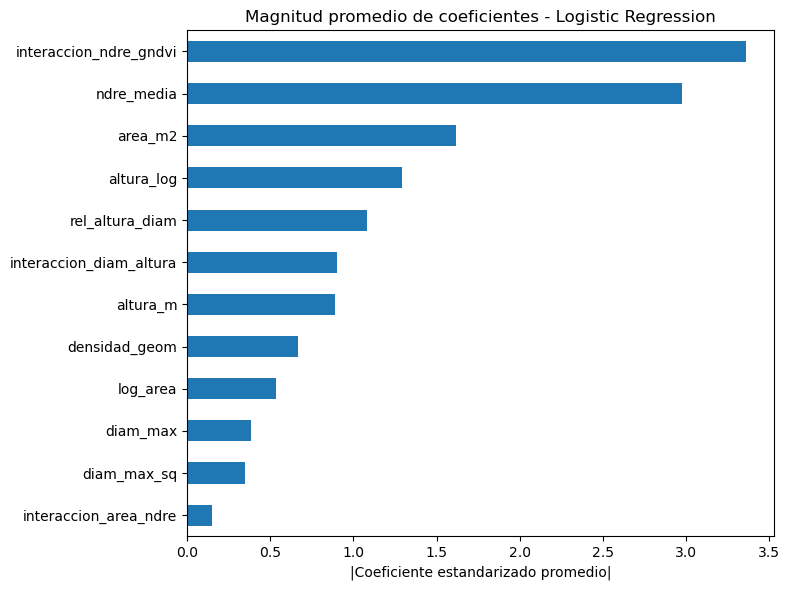

,abs_coef_promedio
interaccion_ndre_gndvi,3.358953
ndre_media,2.976661
area_m2,1.614974
altura_log,1.291661
rel_altura_diam,1.084132
interaccion_diam_altura,0.900229
altura_m,0.886377
densidad_geom,0.668099
log_area,0.534776
diam_max,0.387182



Probabilidades de asignación por clase (Vista de Confianza):


,prob_0-5,prob_10-15,prob_6-9
0,2.601341e-04,0.732546,0.267194
1,4.638774e-09,0.974082,0.025918
2,3.577564e-08,0.976150,0.023850
3,1.203723e-02,0.605931,0.382032
4,1.742391e-09,0.987674,0.012326


In [67]:
# Evaluación desagregada por predio
eval_df = pd.DataFrame({
    "predio": groups,
    "edad_clase_real": y,
    "edad_clase_pred": label_encoder.inverse_transform(y_pred_best)
})

summary_by_predio = []
for predio_name, subdf in eval_df.groupby("predio"):
    acc = accuracy_score(subdf["edad_clase_real"], subdf["edad_clase_pred"])
    bal_acc = balanced_accuracy_score(subdf["edad_clase_real"], subdf["edad_clase_pred"])
    f1_macro = f1_score(subdf["edad_clase_real"], subdf["edad_clase_pred"], average="macro")

    summary_by_predio.append({
        "predio": predio_name,
        "n": len(subdf),
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "f1_macro": f1_macro
    })

summary_by_predio = pd.DataFrame(summary_by_predio)
print("Desempeño auditado por predio individual:")
display(summary_by_predio)

# Ajuste definitivo del modelo en todo el dataset para exportación
best_model.fit(X, y_encoded)
print("\nModelo final ajustado sobre el 100% de los registros históricos.")

# Extracción de métricas de interpretabilidad según la arquitectura ganadora
if best_model_name == "RandomForest":
    model = best_model.named_steps["model"]
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    importances.sort_values().plot(kind="barh")
    plt.title("Importancia de variables - Random Forest")
    plt.xlabel("Importancia Relativa")
    plt.tight_layout()
    plt.show()
    display(importances.to_frame("importancia"))

elif best_model_name == "LogisticRegression":
    model = best_model.named_steps["model"]
    coef_abs_mean = np.mean(np.abs(model.coef_), axis=0)
    coef_series = pd.Series(coef_abs_mean, index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    coef_series.sort_values().plot(kind="barh")
    plt.title("Magnitud promedio de coeficientes - Logistic Regression")
    plt.xlabel("|Coeficiente estandarizado promedio|")
    plt.tight_layout()
    plt.show()
    display(coef_series.to_frame("abs_coef_promedio"))

# Análisis de certidumbre: Probabilidades predichas por clase
if hasattr(best_model, "predict_proba"):
    probas = best_model.predict_proba(X)
    probas_df = pd.DataFrame(probas, columns=[f"prob_{c}" for c in label_encoder.classes_])
    print("\nProbabilidades de asignación por clase (Vista de Confianza):")
    display(probas_df.head())

## Consolidación de Resultados y Exportación para Integración B2B

Para que los resultados sean consumibles por plataformas empresariales, sistemas GIS o tableros de decisiones corporativas, estructuramos y exportamos los datos generados en dos vías independientes:
1. **Archivo de Validación Cruzada:** Contiene el desempeño del modelo simulando escenarios reales "fuera de muestra".
2. **Archivo Corporativo Final:** Contiene las predicciones consolidadas del modelo final entrenado con todo el set de datos, anexando el nivel exacto de confianza predictiva (`confianza_max`) para cada registro georreferenciado.

In [69]:
df_resultados = df_model.copy()
df_resultados["edad_clase_real"] = y.values
df_resultados["edad_clase_pred"] = label_encoder.inverse_transform(best_model.predict(X))

if hasattr(best_model, "predict_proba"):
    probas = best_model.predict_proba(X)
    for i, clase in enumerate(label_encoder.classes_):
        df_resultados[f"prob_{clase}"] = probas[:, i]

# Mapeos estéticos para salida empresarial
reemplazos_clases = {"0-5": "edad 0-5", "6-9": "edad 6-9", "10-15": "edad 10-15"}
rename_probs = {"prob_0-5": "prob_edad_0_5", "prob_6-9": "prob_edad_6_9", "prob_10-15": "prob_edad_10_15"}

# --- EXPORTACIÓN A: DATASET VALIDACIÓN CRUZADA ---
df_cv_export = df_model.copy().reset_index(drop=True)
df_cv_export["edad_clase_real"] = y.astype(str).replace(reemplazos_clases)
df_cv_export["edad_clase_pred_cv"] = pd.Series(label_encoder.inverse_transform(y_pred_best)).astype(str).replace(reemplazos_clases)
df_cv_export["acierto_cv"] = df_cv_export["edad_clase_real"] == df_cv_export["edad_clase_pred_cv"]

columnas_inicio_cv = ["ID", "predio", "edad_aprox", "edad_clase_real", "edad_clase_pred_cv", "acierto_cv"]
columnas_inicio_cv_existentes = [c for c in columnas_inicio_cv if c in df_cv_export.columns]
columnas_restantes_cv = [c for c in df_cv_export.columns if c not in columnas_inicio_cv_existentes]
df_cv_export = df_cv_export[columnas_inicio_cv_existentes + columnas_restantes_cv]

nombre_csv_cv = "predicciones_validacion_cruzada_corregido.csv"
nombre_xlsx_cv = "predicciones_validacion_cruzada_corregido.xlsx"
df_cv_export.to_csv(nombre_csv_cv, index=False, encoding="utf-8-sig")
df_cv_export.to_excel(nombre_xlsx_cv, index=False)

# --- EXPORTACIÓN B: DATASET MODELO FINAL ---
df_final_export = df_resultados.copy()
if "edad_clase_real" in df_final_export.columns:
    df_final_export["edad_clase_real"] = df_final_export["edad_clase_real"].astype(str).replace(reemplazos_clases)
if "edad_clase_pred" in df_final_export.columns:
    df_final_export["edad_clase_pred"] = df_final_export["edad_clase_pred"].astype(str).replace(reemplazos_clases)

for col_old, col_new in rename_probs.items():
    if col_old in df_final_export.columns:
        df_final_export.rename(columns={col_old: col_new}, inplace=True)

columnas_prob = [col for col in df_final_export.columns if col.startswith("prob_edad_")]
if len(columnas_prob) > 0:
    df_final_export["confianza_max"] = df_final_export[columnas_prob].max(axis=1)

if "edad_clase_real" in df_final_export.columns and "edad_clase_pred" in df_final_export.columns:
    df_final_export["acierto"] = df_final_export["edad_clase_real"] == df_final_export["edad_clase_pred"]

columnas_inicio_final = ["ID", "predio", "edad_aprox", "edad_clase_real", "edad_clase_pred", "confianza_max", "acierto", "prob_edad_0_5", "prob_edad_6_9", "prob_edad_10_15"]
columnas_inicio_final_existentes = [c for c in columnas_inicio_final if c in df_final_export.columns]
columnas_restantes_final = [c for c in df_final_export.columns if c not in columnas_inicio_final_existentes]
df_final_export = df_final_export[columnas_inicio_final_existentes + columnas_restantes_final]

nombre_csv_final = "predicciones_modelo_final_corregido.csv"
nombre_xlsx_final = "predicciones_modelo_final_corregido.xlsx"
df_final_export.to_csv(nombre_csv_final, index=False, encoding="utf-8-sig")
df_final_export.to_excel(nombre_xlsx_final, index=False)

print(f"Archivo CV exportado: {nombre_csv_cv}")
print(f"Archivo Final exportado: {nombre_csv_final}")

Archivo CV exportado: predicciones_validacion_cruzada_corregido.csv
Archivo Final exportado: predicciones_modelo_final_corregido.csv


## Cierre del Pipeline Predictivo y Vista Previa de Datos

Con los entregables generados correctamente en el entorno local, visualizamos las primeras filas de los conjuntos estructurados finales. Esto nos asegura que el ordenamiento de columnas, nombres y valores probabilísticos cumplen rigurosamente con los estándares corporativos requeridos.

In [71]:
print("Vista previa - Conjunto de Validación Cruzada (Estructura de Control):")
display(df_cv_export.head())

print("\nVista previa - Conjunto del Modelo Final (Estructura Comercial B2B):")
display(df_final_export.head())

# Despliegue de conclusiones ejecutivas finales
best_metrics = results_df.iloc[0]
print("\n" + "="*60)
print("              CONCLUSIÓN DEL SISTEMA INTELIGENTE")
print("="*60)
print("Modelo de Producción Seleccionado :", best_model_name)
print(f"Accuracy General (CV Espacial)   : {best_metrics['accuracy_cv']:.4f}")
print(f"Balanced Accuracy (Mitigación)  : {best_metrics['balanced_accuracy_cv']:.4f}")
print(f"F1-Macro Score (Métrica Clave)  : {best_metrics['f1_macro_cv']:.4f}")
print("="*60)

Vista previa - Conjunto de Validación Cruzada (Estructura de Control):


,ID,predio,edad_aprox,edad_clase_real,edad_clase_pred_cv,acierto_cv,x,y,ndvi_media,ndvi_max,...,diam_circu,edad_clase,log_area,diam_max_sq,altura_log,rel_altura_diam,densidad_geom,interaccion_diam_altura,interaccion_area_ndre,interaccion_ndre_gndvi
0,AGROSILV_001,silvicultores,10,edad 10-15,edad 6-9,False,569648.9219,2206002.619,0.681852,0.881289,...,2.356944,10-15,1.118088,4.632012,0.686165,0.458172,0.956690,2.122261,0.174029,0.033260
1,AGROSILV_002,silvicultores,10,edad 10-15,edad 10-15,True,569648.5976,2206000.348,0.682127,0.922071,...,3.627464,10-15,1.531693,13.072961,0.872371,0.385152,1.002861,5.035082,0.238761,0.024267
2,AGROSILV_003,silvicultores,10,edad 10-15,edad 10-15,True,569648.0896,2205997.971,0.666949,0.872402,...,3.629513,10-15,1.492904,11.412972,0.785434,0.353241,1.021221,4.031535,0.191886,0.019394
3,AGROSILV_004,silvicultores,10,edad 10-15,edad 10-15,True,569647.5716,2205995.588,0.631413,0.842249,...,2.062912,10-15,0.814922,3.522390,0.577041,0.416006,0.670821,1.465336,0.057267,0.014430
4,AGROSILV_005,silvicultores,10,edad 10-15,edad 10-15,True,569647.1305,2205993.296,0.678549,0.953309,...,3.406569,10-15,1.503188,9.710783,0.953951,0.512143,1.121874,4.973311,0.168682,0.016677



Vista previa - Conjunto del Modelo Final (Estructura Comercial B2B):


,ID,predio,edad_aprox,edad_clase_real,edad_clase_pred,confianza_max,acierto,prob_edad_0_5,prob_edad_6_9,prob_edad_10_15,...,diam_circu,edad_clase,log_area,diam_max_sq,altura_log,rel_altura_diam,densidad_geom,interaccion_diam_altura,interaccion_area_ndre,interaccion_ndre_gndvi
0,AGROSILV_001,silvicultores,10,edad 10-15,edad 10-15,0.732546,True,2.601341e-04,0.267194,0.732546,...,2.356944,10-15,1.118088,4.632012,0.686165,0.458172,0.956690,2.122261,0.174029,0.033260
1,AGROSILV_002,silvicultores,10,edad 10-15,edad 10-15,0.974082,True,4.638774e-09,0.025918,0.974082,...,3.627464,10-15,1.531693,13.072961,0.872371,0.385152,1.002861,5.035082,0.238761,0.024267
2,AGROSILV_003,silvicultores,10,edad 10-15,edad 10-15,0.976150,True,3.577564e-08,0.023850,0.976150,...,3.629513,10-15,1.492904,11.412972,0.785434,0.353241,1.021221,4.031535,0.191886,0.019394
3,AGROSILV_004,silvicultores,10,edad 10-15,edad 10-15,0.605931,True,1.203723e-02,0.382032,0.605931,...,2.062912,10-15,0.814922,3.522390,0.577041,0.416006,0.670821,1.465336,0.057267,0.014430
4,AGROSILV_005,silvicultores,10,edad 10-15,edad 10-15,0.987674,True,1.742391e-09,0.012326,0.987674,...,3.406569,10-15,1.503188,9.710783,0.953951,0.512143,1.121874,4.973311,0.168682,0.016677



              CONCLUSIÓN DEL SISTEMA INTELIGENTE
Modelo de Producción Seleccionado : LogisticRegression
Accuracy General (CV Espacial)   : 0.8129
Balanced Accuracy (Mitigación)  : 0.8089
F1-Macro Score (Métrica Clave)  : 0.7971
